# UK Mobile Telecom Revenue Analysis

**Research question:** How do UK mobile retail revenues evolve alongside subscriptions, subscriber mix and usage?

This notebook uses historical quarterly observations in the **Q1 2026 release**, ending in 2026 Q1. Annual totals are excluded. The observation unit is the UK mobile market in a quarter, not an operator or an individual customer. Monetary amounts are nominal; no inflation adjustment is implied.

Source: [Ofcom Telecommunications Market Data Update](https://www.ofcom.org.uk/phones-and-broadband/telecoms-infrastructure/telecommunications-market-data-update), published 23 July 2026. Historical values can be restated; comparisons use the same release throughout.

In [1]:
from pathlib import Path
import csv, re, hashlib, json, platform, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True})
RESULTS = Path('analysis_outputs'); RESULTS.mkdir(exist_ok=True)
print('Python', platform.python_version())

Python 3.13.9


## 1. Load and preserve the source
The source is a multi-table CSV, not a single rectangular dataset. We isolate the mobile section, read its individual headers, and select quarterly rows using an explicit pattern. Blank or suppressed values become missing, never zero. Percentage fields are stored as fractions. Raw data is preserved and hashed for provenance.

In [2]:
SOURCE_URL = 'https://www.ofcom.org.uk/siteassets/resources/documents/research-and-data/telecoms-research/telecoms-data-updates/telecommunications-market-data/telecommunications-market-data-update-q1-2026.csv'
RAW = Path('ofcom_q1_2026.csv')
if not RAW.exists():
    request = urllib.request.Request(SOURCE_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(request, timeout=60) as response:
        RAW.write_bytes(response.read())
blob = RAW.read_bytes()
provenance = {'source_url': SOURCE_URL, 'release': 'Q1 2026',
              'sha256': hashlib.sha256(blob).hexdigest(), 'bytes': len(blob)}
(RESULTS / 'provenance.json').write_text(json.dumps(provenance, indent=2))
try:
    text = blob.decode('utf-8-sig')
except UnicodeDecodeError:
    text = blob.decode('cp1252')
rows = list(csv.reader(text.splitlines()))
start = next(i for i, row in enumerate(rows) if row and row[0].strip() == 'Mobile tables')
tables = {}
for i in range(start, len(rows)):
    row = rows[i]
    if not row or not re.match(r'Table [1-5]:', row[0]):
        continue
    table_number = int(re.search(r'Table (\d+)', row[0]).group(1))
    end = next((j for j in range(i+1, len(rows)) if rows[j] and rows[j][0].startswith('Table ')), len(rows))
    header_index = next(j for j in range(i+1, end) if rows[j] and not rows[j][0].strip() and any(v.strip() for v in rows[j][1:]))
    headers = rows[header_index]
    columns = [(k, name.strip()) for k, name in enumerate(headers) if k > 0 and name.strip()]
    records = []
    for r in rows[header_index+1:end]:
        if r and re.fullmatch(r'\d{4} Q[1-4]', r[0].strip()):
            record = {'quarter': r[0].strip().replace(' ', '')}
            for k, name in columns:
                value = r[k].strip() if k < len(r) else ''
                percent = value.endswith('%')
                number = pd.to_numeric(value.replace(',', '').replace('%', ''), errors='coerce')
                record[name] = number / 100 if percent else number
            records.append(record)
    frame = pd.DataFrame(records).set_index('quarter')
    frame.index = pd.PeriodIndex(frame.index, freq='Q')
    assert frame.index.is_unique, f'Duplicate quarters in table {table_number}'
    tables[table_number] = frame.sort_index()
assert set(tables) == {1, 2, 3, 4, 5}, 'Unexpected Ofcom mobile table structure'
display(pd.DataFrame({k: {'rows': len(v), 'first': str(v.index.min()), 'last': str(v.index.max())} for k,v in tables.items()}).T)
display(provenance)

,rows,first,last
1,77,2007Q1,2026Q1
2,77,2007Q1,2026Q1
3,77,2007Q1,2026Q1
4,77,2007Q1,2026Q1
5,77,2007Q1,2026Q1


{'source_url': 'https://www.ofcom.org.uk/siteassets/resources/documents/research-and-data/telecoms-research/telecoms-data-updates/telecommunications-market-data/telecommunications-market-data-update-q1-2026.csv',
 'release': 'Q1 2026',
 'sha256': '602bbbff5851a870c0719e9e92e1608eeeb80c9d2d37ca583c0aaebea3c396b3',
 'bytes': 129657}

## 2. Clean and validate
Revenue: £million per quarter. Subscribers: millions at quarter end (source scope excludes M2M; consult source notes for definition changes). Voice/messages: billions per quarter; data: PB per quarter. ARPU: £ per subscriber per month. End-period subscriber counts do not reproduce Ofcom ARPU denominators exactly.

We keep missingness visible, align on quarters and truncate at 2026 Q1. No interpolation or silent removal of outliers is applied. Data availability and methodology changes may limit the usable window.

In [3]:
series = {
    'revenue_gbp_m': tables[1]['Total'],
    'bundled_revenue_gbp_m': tables[1]['Access and bundled svcs'],
    'subscribers_m': tables[3]['Total subs at end of period'],
    'postpay_share': tables[3]['Proportion post-pay'],
    'voice_bn': tables[2]['All calls'],
    'messages_bn': tables[2]['SMS & MMS messages'],
    'data_pb': tables[2]['Data'],
    'arpu_gbp_month': tables[4]['All subscribers'],
}
df = pd.DataFrame(series).sort_index().loc[:'2026Q1']
assert df.index.max() == pd.Period('2026Q1'), 'Target quarter absent'
expected = pd.period_range(df.index.min(), df.index.max(), freq='Q')
assert df.index.equals(expected), 'Quarter gaps require explicit review'
assert df['revenue_gbp_m'].notna().all()
assert (df.drop(columns='postpay_share').dropna() >= 0).all().all()
assert df['postpay_share'].dropna().between(0, 1).all()
assert abs(df.loc['2026Q1', 'revenue_gbp_m'] - 3570) <= 2, 'Revenue disagrees with published rounded headline'
display(df.isna().sum().rename('missing_quarters').to_frame())
display(df.tail())
df.to_csv(RESULTS / 'mobile_quarterly_clean.csv')

,missing_quarters
revenue_gbp_m,0
bundled_revenue_gbp_m,0
subscribers_m,0
postpay_share,0
voice_bn,0
messages_bn,0
data_pb,23
arpu_gbp_month,0


,revenue_gbp_m,bundled_revenue_gbp_m,subscribers_m,postpay_share,voice_bn,messages_bn,data_pb,arpu_gbp_month
quarter,,,,,,,,
2025Q1,3515,3001,89.70,0.7549,38.10,5.86,2691.0,13.04
2025Q2,3686,3140,89.98,0.7547,37.09,5.44,2911.0,13.68
2025Q3,3687,3125,91.04,0.7521,36.86,5.24,3055.0,13.58
2025Q4,3617,3090,91.06,0.7573,37.11,4.96,3087.0,13.24
2026Q1,3570,3086,90.58,0.7621,36.34,4.61,3042.0,13.10


## 3. Exploratory analysis
Examine distributions, trends, quarter-on-quarter changes and year-on-year changes. Annual observations are not mixed into quarterly growth. Bundled revenues describe composition rather than an independent explanatory variable.

,count,mean,std,min,25%,50%,75%,max
revenue_gbp_m,77.0,3657.740260,310.882632,3034.000,3438.000,3704.000,3925.000,4117.0000
bundled_revenue_gbp_m,77.0,2366.766234,529.663719,1451.000,1830.000,2545.000,2787.000,3140.0000
subscribers_m,77.0,83.246753,4.368924,70.730,81.830,83.670,85.160,91.0600
postpay_share,77.0,0.603605,0.135792,0.353,0.484,0.638,0.738,0.7621
voice_bn,77.0,36.931429,5.413690,25.020,32.900,36.880,40.340,49.6000
messages_bn,77.0,19.998052,10.136272,4.610,10.480,19.090,26.990,39.3900
data_pb,54.0,1167.537037,1003.326669,57.000,285.250,834.500,2123.500,3087.0000
arpu_gbp_month,77.0,14.782597,1.751807,12.100,13.240,15.580,16.020,21.0700


,qoq_pct,yoy_pct
quarter,,
2024Q2,5.048430,2.785755
2024Q3,0.195585,1.730496
2024Q4,-0.418293,2.379587
2025Q1,-1.568188,3.169944
2025Q2,4.864865,2.989662
2025Q3,0.027130,2.816509
2025Q4,-1.898563,1.288155
2026Q1,-1.299419,1.564723


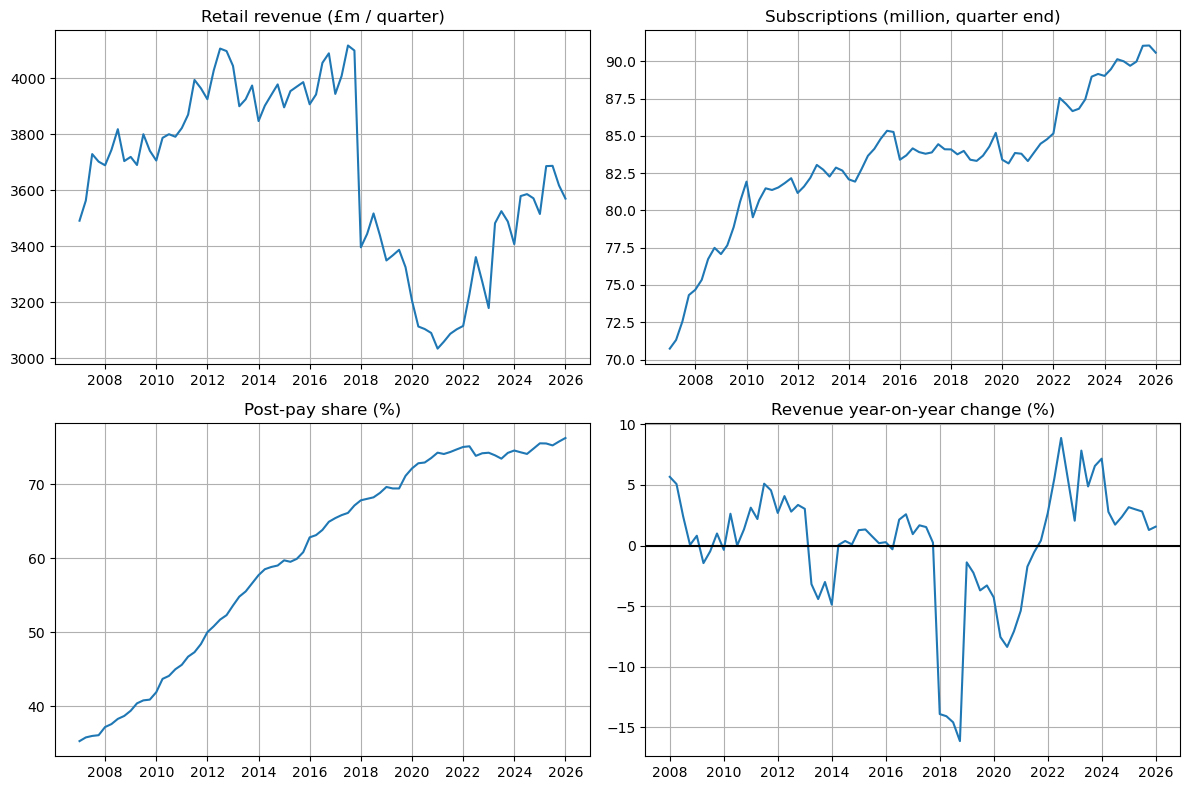

quarter
2025Q1    85.376956
2025Q2    85.187195
2025Q3    84.757255
2025Q4    85.429914
2026Q1    86.442577
Freq: Q-DEC, Name: bundled_revenue_share_pct, dtype: float64

In [4]:
display(df.describe().T)
growth = pd.DataFrame({'qoq_pct': df.revenue_gbp_m.pct_change(fill_method=None)*100,
                       'yoy_pct': df.revenue_gbp_m.pct_change(4, fill_method=None)*100})
display(growth.tail(8))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
time = df.index.to_timestamp()
axes[0,0].plot(time, df.revenue_gbp_m); axes[0,0].set_title('Retail revenue (£m / quarter)')
axes[0,1].plot(time, df.subscribers_m); axes[0,1].set_title('Subscriptions (million, quarter end)')
axes[1,0].plot(time, df.postpay_share*100); axes[1,0].set_title('Post-pay share (%)')
axes[1,1].plot(time, growth.yoy_pct); axes[1,1].axhline(0, color='black'); axes[1,1].set_title('Revenue year-on-year change (%)')
fig.tight_layout(); plt.show()
display((100*df.bundled_revenue_gbp_m/df.revenue_gbp_m).tail().rename('bundled_revenue_share_pct'))

## 4. Correlations and hypotheses
**H1:** Subscriber growth is positively associated with revenue growth (null: coefficient = 0).
**H2:** Change in post-pay share is associated with revenue growth (null: coefficient = 0; expected sign positive).
**H3:** Data traffic growth is associated with revenue growth (exploratory; no causal interpretation).

Pearson and Spearman correlations in levels can reflect shared trends. First-difference/log-growth correlations are a sensitivity check. The level-count matrix reports 77 observations for pairs without data traffic, and 54 for pairs involving data traffic. The change correlations use 76 observations for pairs without data traffic and 53 for pairs involving data traffic, reflecting differencing and missing early traffic observations. Hypotheses were specified before fitting here; exploratory expansion requires multiplicity control.

,revenue_gbp_m,subscribers_m,postpay_share,voice_bn,messages_bn,data_pb
revenue_gbp_m,77,77,77,77,77,54
subscribers_m,77,77,77,77,77,54
postpay_share,77,77,77,77,77,54
voice_bn,77,77,77,77,77,54
messages_bn,77,77,77,77,77,54
data_pb,54,54,54,54,54,54


,revenue_gbp_m,subscribers_m,postpay_share,voice_bn,messages_bn,data_pb
revenue_gbp_m,1.000000,-0.206611,-0.509649,-0.676494,0.708632,-0.497011
subscribers_m,-0.206611,1.000000,0.869164,0.646411,-0.463020,0.918691
postpay_share,-0.509649,0.869164,1.000000,0.873868,-0.674786,0.845482
voice_bn,-0.676494,0.646411,0.873868,1.000000,-0.568329,0.335309
messages_bn,0.708632,-0.463020,-0.674786,-0.568329,1.000000,-0.908753
data_pb,-0.497011,0.918691,0.845482,0.335309,-0.908753,1.000000


,revenue_gbp_m,subscribers_m,postpay_share,voice_bn,messages_bn,data_pb
revenue_gbp_m,1.000000,-0.294184,-0.536277,-0.605244,0.723883,-0.568668
subscribers_m,-0.294184,1.000000,0.910125,0.725224,-0.669550,0.804285
postpay_share,-0.536277,0.910125,1.000000,0.864329,-0.759934,0.969944
voice_bn,-0.605244,0.725224,0.864329,1.000000,-0.609946,0.569909
messages_bn,0.723883,-0.669550,-0.759934,-0.609946,1.000000,-0.997865
data_pb,-0.568668,0.804285,0.969944,0.569909,-0.997865,1.000000


,revenue_gbp_m,subscribers_m,voice_bn,messages_bn,data_pb,postpay_share_change
revenue_gbp_m,1.000000,0.251802,-0.264757,0.207161,0.178156,-0.321866
subscribers_m,0.251802,1.000000,-0.125448,0.394857,0.082086,-0.471015
voice_bn,-0.264757,-0.125448,1.000000,0.001047,0.094841,0.317383
messages_bn,0.207161,0.394857,0.001047,1.000000,0.251132,-0.065187
data_pb,0.178156,0.082086,0.094841,0.251132,1.000000,-0.107586
postpay_share_change,-0.321866,-0.471015,0.317383,-0.065187,-0.107586,1.000000


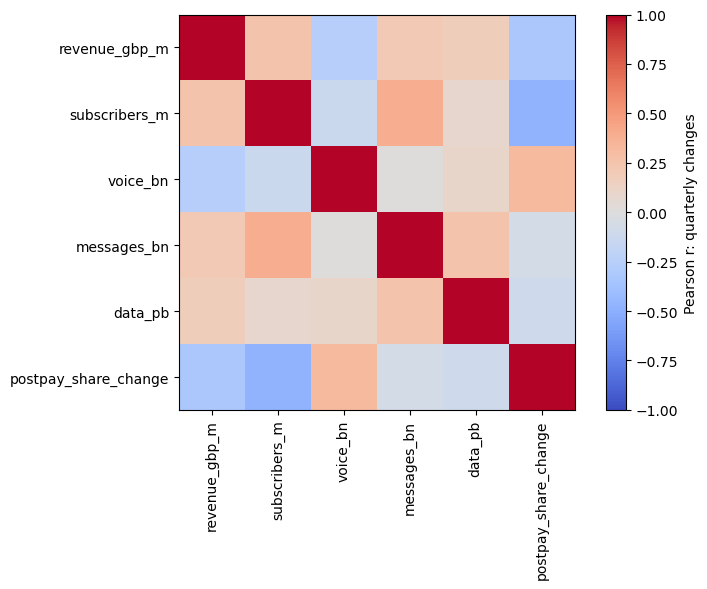

In [5]:
features = ['revenue_gbp_m','subscribers_m','postpay_share','voice_bn','messages_bn','data_pb']
levels = df[features]
changes = np.log(levels.drop(columns='postpay_share').where(levels.drop(columns='postpay_share') > 0)).diff()
changes['postpay_share_change'] = df.postpay_share.diff()
display(levels.notna().astype(int).T @ levels.notna().astype(int))
display(levels.corr(method='pearson'))
display(levels.corr(method='spearman'))
display(changes.corr())
fig, ax = plt.subplots(figsize=(8,6))
corr = changes.corr(); im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(corr)), corr.columns, rotation=90); ax.set_yticks(range(len(corr)), corr.columns)
fig.colorbar(im, ax=ax, label='Pearson r: quarterly changes'); ax.grid(False)
plt.tight_layout(); plt.show()

All reported hypothesis tests are two-sided. A positive association requires a positive estimated coefficient as well as statistical evidence.” The current code tests whether coefficients differ from zero, rather than testing only a positive effect.

## 5. Regression framework
Primary specification: quarterly log revenue growth explained by log subscriber growth, change in post-pay share (percentage points), and seasonal quarter indicators. A recent window starting in 2019 reduces exposure to older billing/methodology regimes, but does not guarantee comparability. Verify source notes before changing this window.

HAC standard errors (four lags) address heteroskedasticity and short-run dependence, without resolving omitted variables, structural breaks or endogeneity. H3 is a separate sensitivity specification because data coverage is shorter. ARPU and component revenue are excluded to avoid accounting leakage. A final four-quarter chronological holdout evaluates predictions; random train/test splitting would leak future information.

In [7]:
model_data = pd.DataFrame({
    'revenue_growth': np.log(df.revenue_gbp_m).diff(),
    'subscriber_growth': np.log(df.subscribers_m).diff(),
    'postpay_change_pp': df.postpay_share.diff()*100,
    'data_growth': np.log(df.data_pb.where(df.data_pb > 0)).diff(),
}).loc['2019Q1':]
base = model_data.dropna(subset=['revenue_growth','subscriber_growth','postpay_change_pp']).copy()
assert len(base) >= 20, 'Too few complete quarters for the proposed framework'
def design(frame, include_data=False):
    cols = ['subscriber_growth','postpay_change_pp'] + (['data_growth'] if include_data else [])
    X = frame[cols].copy()
    for q in [2,3,4]: X[f'Q{q}'] = (frame.index.quarter == q).astype(float)
    return sm.add_constant(X, has_constant='add').astype(float)
X = design(base); y = base.revenue_growth
assert np.linalg.matrix_rank(X) == X.shape[1], 'Singular model matrix'
ols = sm.OLS(y, X).fit()
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':4})
display(model.summary())
tests = pd.DataFrame({'coefficient': model.params[['subscriber_growth','postpay_change_pp']],
                      'p_value_HAC': model.pvalues[['subscriber_growth','postpay_change_pp']]})
tests['p_value_Holm'] = multipletests(tests.p_value_HAC, method='holm')[1]
display(tests)
extended = model_data.dropna()
if len(extended) >= 20:
    sensitivity = sm.OLS(extended.revenue_growth, design(extended, True)).fit(cov_type='HAC', cov_kwds={'maxlags':4})
    display(sensitivity.summary())
else:
    print('H3 deferred: fewer than 20 complete observations.')
train, test = base.iloc[:-4], base.iloc[-4:]
fitted = sm.OLS(train.revenue_growth, design(train)).fit()
prediction = fitted.predict(design(test))
baseline = pd.Series(train.revenue_growth.mean(), index=test.index)
scores = pd.DataFrame({'actual': test.revenue_growth, 'prediction': prediction, 'training_mean_baseline': baseline})
display(scores)
display(pd.Series({'model_MAE_log_growth': np.mean(abs(test.revenue_growth-prediction)),
                   'baseline_MAE_log_growth': np.mean(abs(test.revenue_growth-baseline))}))
scores.to_csv(RESULTS / 'holdout_predictions.csv')

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         revenue_growth   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     21.30
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           6.13e-08
Time:                        23:15:48   Log-Likelihood:                 76.715
No. Observations:                  29   AIC:                            -141.4
Df Residuals:                      23   BIC:                            -133.2
Df Model:                           5                                         
Covariance Type:                  HAC                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0022      0.006     -0.362      0.717      -0.014       0.010
subscriber_growth     0.6484      0.324      2.000      0.046       0.013       1.284
postpay_change_pp    -0.0270      0.006     -4.779      0.000      -0.038      -0.016
Q2                    0.0264      0.019      1.423      0.155      -0.010       0.063
Q3                   -0.0004      0.009     -0.043      0.966      -0.019       0.018
Q4                    0.0095      0.005      1.933      0.053      -0.000       0.019
==============================================================================
Omnibus:                        4.490   Durbin-Watson:                   2.540
Prob(Omnibus):                  0.106   Jarque-Bera (JB):                3.080
Skew:                           0.446   Prob(JB):                        0.214
Kurtosis:                       4.325   Cond. No.                         162.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 4 lags and without small sample correction
"""

,coefficient,p_value_HAC,p_value_Holm
subscriber_growth,0.648402,0.045521,0.045521
postpay_change_pp,-0.026982,0.000002,0.000004


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         revenue_growth   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     19.67
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           8.22e-08
Time:                        23:15:49   Log-Likelihood:                 76.764
No. Observations:                  29   AIC:                            -139.5
Df Residuals:                      22   BIC:                            -130.0
Df Model:                           6                                         
Covariance Type:                  HAC                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0013      0.005     -0.275      0.783      -0.011       0.008
subscriber_growth     0.6009      0.415      1.449      0.147      -0.212       1.414
postpay_change_pp    -0.0274      0.006     -4.901      0.000      -0.038      -0.016
data_growth          -0.0343      0.098     -0.349      0.727      -0.227       0.158
Q2                    0.0284      0.023      1.254      0.210      -0.016       0.073
Q3                    0.0016      0.014      0.118      0.906      -0.025       0.028
Q4                    0.0102      0.006      1.694      0.090      -0.002       0.022
==============================================================================
Omnibus:                        3.607   Durbin-Watson:                   2.551
Prob(Omnibus):                  0.165   Jarque-Bera (JB):                2.161
Skew:                           0.391   Prob(JB):                        0.339
Kurtosis:                       4.085   Cond. No.                         172.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 4 lags and without small sample correction
"""

,actual,prediction,training_mean_baseline
quarter,,,
2025Q2,0.047502,0.022741,0.000886
2025Q3,0.000271,0.014434,0.000886
2025Q4,-0.019168,-0.004462,0.000886
2026Q1,-0.013079,-0.019512,0.000886


model_MAE_log_growth       0.015016
baseline_MAE_log_growth    0.020313
dtype: float64

## 6. Diagnostics and robustness
Residual plots, Q–Q plots, Ljung–Box tests, Breusch–Pagan tests, VIF and influence flags are screening tools. Small samples reduce test power. The conventional diagnostic tests below use ordinary OLS residuals; reported coefficient uncertainty uses HAC. Flagged observations remain in the model. A high Cook's distance warrants source/context review, not automatic deletion.

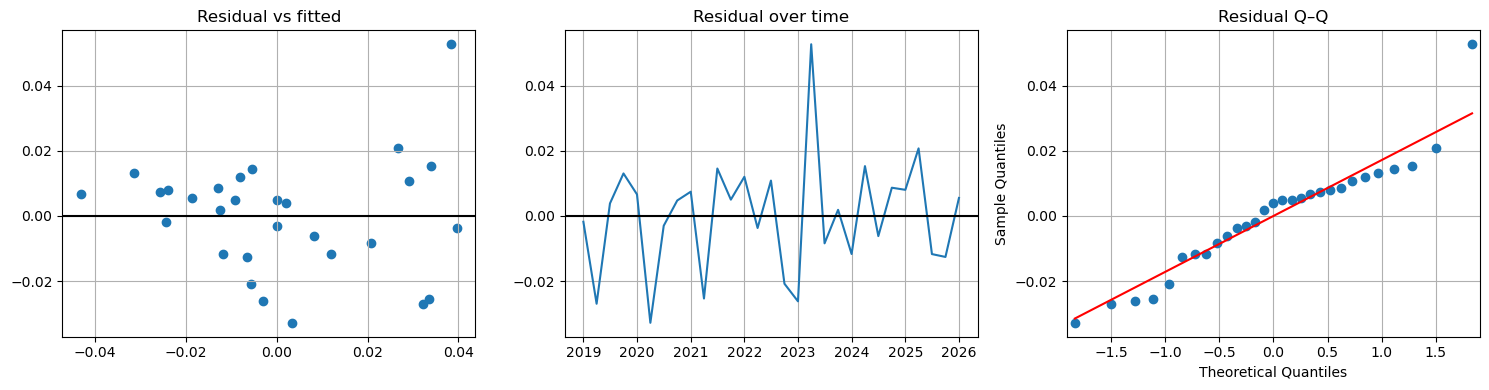

Breusch_Pagan_LM_p    0.062450
Jarque_Bera_p         0.214404
Durbin_Watson         2.539678
dtype: float64

,lb_stat,lb_pvalue
1,2.372226,0.123511
4,8.183298,0.085090


subscriber_growth    1.508171
postpay_change_pp    2.101203
Q2                   2.401888
Q3                   2.887138
Q4                   1.551619
Name: VIF, dtype: float64

,cooks_distance,screening_flag
quarter,,
2020Q2,0.419166,True
2023Q2,0.299953,True
2023Q1,0.103821,False
2019Q4,0.094745,False
2022Q3,0.091795,False


In [8]:
resid = ols.resid
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].scatter(ols.fittedvalues, resid); axes[0].axhline(0, color='black'); axes[0].set_title('Residual vs fitted')
axes[1].plot(base.index.to_timestamp(), resid); axes[1].axhline(0,color='black'); axes[1].set_title('Residual over time')
sm.qqplot(resid, line='s', ax=axes[2]); axes[2].set_title('Residual Q–Q')
plt.tight_layout(); plt.show()
bp = het_breuschpagan(resid, X)
jb = jarque_bera(resid)
display(pd.Series({'Breusch_Pagan_LM_p':bp[1], 'Jarque_Bera_p':jb[1], 'Durbin_Watson':durbin_watson(resid)}))
display(acorr_ljungbox(resid, lags=[1,4], return_df=True))
display(pd.Series({name: variance_inflation_factor(X.values, i) for i,name in enumerate(X.columns) if name != 'const'}, name='VIF'))
influence = pd.DataFrame({'cooks_distance':ols.get_influence().cooks_distance[0]}, index=base.index)
influence['screening_flag'] = influence.cooks_distance > 4/len(base)
display(influence.sort_values('cooks_distance', ascending=False).head())
model.params.to_csv(RESULTS / 'HAC_coefficients.csv')
tests.to_csv(RESULTS / 'hypothesis_tests.csv')

## 7. Findings, interpretation and limitations

### Market position in Q1 2026
Retail mobile revenue was **GBP 3,570 million**, up **1.56% year on year** and down **1.30% quarter on quarter**, using the rounded values in this release. Subscriptions stood at **90.58 million**; post-pay represented **76.21%**. Access and bundled services accounted for **86.44%** of retail revenue. These are nominal amounts, not inflation-adjusted revenue growth.

### Correlations
Across the historical sample, revenue levels correlate negatively with subscriber counts (Pearson r = -0.207) and data traffic (r = -0.497). In quarterly log changes, these correlations become positive but modest: **0.252** for subscriber growth and **0.178** for data growth. The contrast illustrates why trending levels should not be interpreted as causal evidence. Changes in post-pay share correlate negatively with revenue growth (r = -0.322). Traffic correlations use a shorter sample because 23 historical quarters lack traffic values.

### Primary regression and hypotheses
The 2019 Q1–2026 Q1 model uses **29 quarterly growth observations**, including the change from 2018 Q4 to 2019 Q1, with seasonal indicators and four-lag HAC standard errors. Its R-squared is **0.625** and adjusted R-squared **0.544**; these describe in-sample fit, not causal explanation or forecasting accuracy.

| Hypothesis | Estimate and evidence | Interpretation |
|---|---|---|
| H1: subscriber growth has a positive association | Coefficient 0.648; 95% HAC CI [0.013, 1.284]; Holm-adjusted p = 0.0455 | The primary model provides borderline evidence in the expected direction. A 1% subscriber increase is associated with approximately 0.65% higher revenue, conditional on the included terms. |
| H2: post-pay mix change has an association, expected positive | Coefficient -0.02698 per percentage point; 95% HAC CI approximately [-0.038, -0.016]; Holm-adjusted p approximately 0.000004 | Evidence of an association is present, but its direction is negative, contrary to the positive expectation. A one-percentage-point increase corresponds to approximately 2.7% lower revenue, conditional on the included terms. This is not evidence that shifting customers to post-pay causes revenue to fall. |
| H3: data growth has an association (exploratory) | Extended-model coefficient -0.0343; 95% HAC CI [-0.227, 0.158]; p = 0.727 | The extended specification does not provide clear evidence of an independent data-growth association. This does not establish absence of an effect. |

All tests are two-sided. Holm correction applies to H1 and H2, not the exploratory H3. Adding data growth increases R-squared only from 0.625 to 0.627 and lowers adjusted R-squared to 0.525. The subscriber coefficient falls to 0.601 with p = 0.147, so **H1 is sensitive to specification**. The negative post-pay association remains in the extended model.

### Diagnostics and conditional prediction
Breusch-Pagan p = **0.0624**, Jarque-Bera p = **0.2144**, and Ljung-Box p-values at lags 1 and 4 are **0.1235** and **0.0851**. These tests do not reject their nulls at 5%, but the small sample and near-threshold values prevent concluding that all assumptions are satisfied. Durbin-Watson is **2.54**. Predictor VIF values are approximately **1.51–2.89**, with no high VIF flag in this design.

Cook's-distance screening flags **2020 Q2 (0.419)** and **2023 Q2 (0.300)**, exceeding 4/29. Both observations remain included. Their influence should be examined in additional sensitivity analyses before strong conclusions are drawn; those analyses have not been performed in this notebook.

On the four-quarter holdout, **2025 Q2–2026 Q1**, model MAE is **0.0150 log-growth units**, compared with **0.0203** for the training-mean baseline: approximately **26% lower error**. This is limited evidence from four observations. The model uses contemporaneous observed predictors, so this is a conditional prediction exercise, not an advance forecasting system.

### Limitations and conclusion
The 2019 start date is a modelling choice. Alternative windows and influence sensitivity have not been tested. HAC inference here uses asymptotic normal approximations without small-sample correction, so the borderline subscriber result warrants particular caution. Inflation, prices, bundling, pandemic disruption, subscription-definition changes, endogeneity and historical restatements can affect estimates. Aggregate UK observations cannot establish customer or operator behaviour, and this notebook does not test cointegration.

Revenue rose modestly year on year in Q1 2026 despite a quarterly decline. Subscriber growth has a positive association in the primary model but weaker evidence in the extended specification. Post-pay mix change has a negative conditional association, while data growth adds little clear statistical evidence. These findings describe the selected historical sample and warrant further robustness checks before informing business decisions.
